# Campaign ROI Analyzer

Predict donation amounts and identify which campaigns and channels drive the highest donations.

## 1. Problem Framing

**Business Problem:** Lighthouse Philippines runs multiple fundraising campaigns across different channels. Leadership needs to understand which campaigns generate the best return and what factors drive larger donations.

**Target variable:** `amount` — continuous (PHP), regression task on monetary donations.

| Approach | Goal | Method |
|----------|------|--------|
| **Explanatory** | Understand *what drives* donation size | OLS Regression (statsmodels, log-transformed) |
| **Predictive** | Predict donation amount for new donations | GradientBoostingRegressor (sklearn Pipeline) |

## 2. Data Preparation & Exploration

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan

sns.set_style("whitegrid")
SEED = 42
import pymssql
import re as _re

# ── Azure SQL connection ─────────────────────────────────────────────────────
SERVER = 'lunas-project-intex-sql.database.windows.net'
DATABASE = 'lunas-project-db'
USER = 'sqladmin'
PASSWORD = 'M0nson10!'

conn = pymssql.connect(server=SERVER, user=USER, password=PASSWORD,
                       database=DATABASE, port=1433, tds_version='7.3')

def load_table(table_name):
    df = pd.read_sql(f'SELECT * FROM {table_name}', conn)
    df.columns = [_re.sub(r'(?<!^)(?=[A-Z])', '_', c).lower() for c in df.columns]
    return df

# ── Load data ────────────────────────────────────────────────────────────────
donations  = load_table('Donations')
supporters = load_table('Supporters')
sm_posts   = load_table('SocialMediaPosts')

# ── Filter to monetary donations ─────────────────────────────────────────────
df_monetary = donations[
    (donations["donation_type"] == "Monetary") & (donations["amount"].notna())
].copy()
print(f"Monetary donations with amount: {len(df_monetary)}")

# ── Join supporter info ──────────────────────────────────────────────────────
supporter_cols = ["supporter_id", "supporter_type", "relationship_type",
                  "acquisition_channel", "status", "first_donation_date"]
df = df_monetary.merge(supporters[supporter_cols], on="supporter_id", how="left")

df["donation_date"] = pd.to_datetime(df["donation_date"])
df["first_donation_date"] = pd.to_datetime(df["first_donation_date"])

# ── Feature engineering ──────────────────────────────────────────────────────
df["campaign_label"] = df["campaign_name"].fillna("NoCampaign")
df["has_campaign"] = (df["campaign_name"].notna()).astype(int)
df["is_recurring"] = df["is_recurring"].astype(int)
df["days_since_first_donation"] = (df["donation_date"] - df["first_donation_date"]).dt.days.clip(lower=0)

# Prior donation count per supporter (before this donation)
df = df.sort_values(["supporter_id", "donation_date"])
df["prior_donation_count"] = df.groupby("supporter_id").cumcount()
prior_totals = df.groupby("supporter_id")["amount"].expanding().sum().shift(1).reset_index(level=0, drop=True)
df["prior_total_amount"] = prior_totals.fillna(0)

# Join referral post info
if "referral_post_id" in df.columns:
    post_cols = ["post_id", "platform", "engagement_rate"]
    df = df.merge(
        sm_posts[post_cols].rename(columns={"post_id": "referral_post_id"}),
        on="referral_post_id", how="left"
    )
    df.rename(columns={"platform": "referral_platform"}, inplace=True)
    df["has_referral_post"] = df["referral_platform"].notna().astype(int)
    df["referral_engagement_rate"] = df["engagement_rate"].fillna(0)
else:
    df["has_referral_post"] = 0
    df["referral_engagement_rate"] = 0

print(f"Final dataset: {df.shape}")
df.head()

Monetary donations with amount: 234
Final dataset: (234, 27)


,donation_id,supporter_id,donation_type,donation_date,is_recurring,campaign_name,channel_source,currency_code,amount,estimated_value,...,first_donation_date,campaign_label,has_campaign,days_since_first_donation,prior_donation_count,prior_total_amount,referral_platform,engagement_rate,has_referral_post,referral_engagement_rate
0,145,1,Monetary,2023-03-25,1,,SocialMedia,PHP,774.61,774.61,...,2023-07-02,,1,0,0,0.00,Instagram,0.04,1,0.04
1,295,1,Monetary,2023-07-01,1,,Event,PHP,663.94,663.94,...,2023-07-02,,1,0,1,774.61,NaN,NaN,0,0.00
2,353,1,Monetary,2023-12-20,1,,Direct,PHP,2628.14,2628.14,...,2023-07-02,,1,171,2,1438.55,NaN,NaN,0,0.00
3,62,1,Monetary,2024-01-08,1,,Direct,PHP,1392.10,1392.10,...,2023-07-02,,1,190,3,4066.69,NaN,NaN,0,0.00
4,161,1,Monetary,2024-10-17,1,,SocialMedia,PHP,1042.36,1042.36,...,2023-07-02,,1,473,4,5458.79,TikTok,0.08,1,0.08


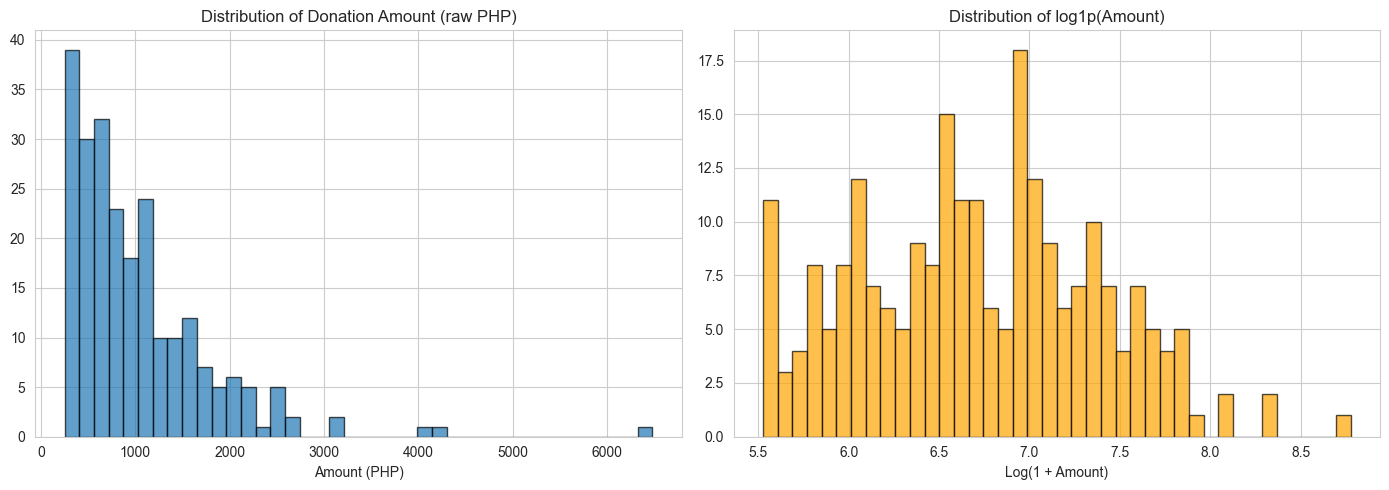

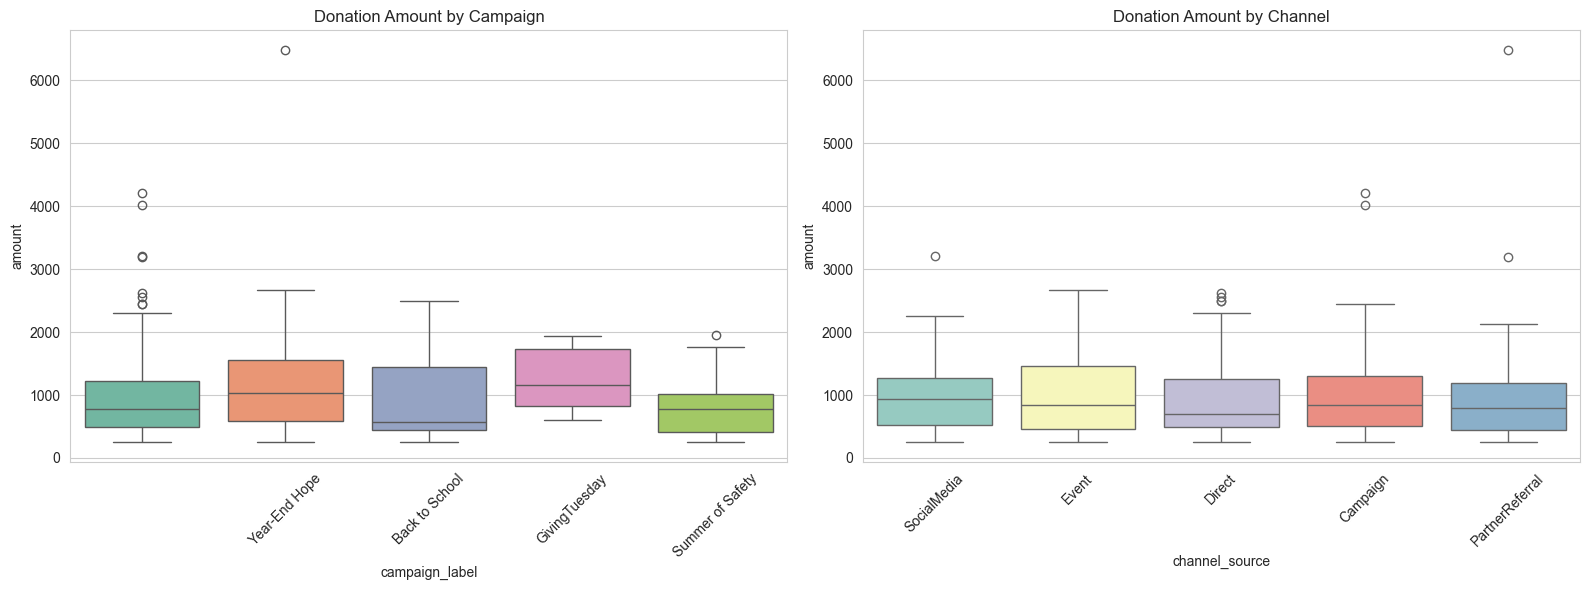

In [2]:
# ── EDA: target distribution and boxplots ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df["amount"], bins=40, edgecolor="k", alpha=0.7)
axes[0].set_title("Distribution of Donation Amount (raw PHP)")
axes[0].set_xlabel("Amount (PHP)")

log_amount = np.log1p(df["amount"])
axes[1].hist(log_amount, bins=40, edgecolor="k", alpha=0.7, color="orange")
axes[1].set_title("Distribution of log1p(Amount)")
axes[1].set_xlabel("Log(1 + Amount)")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
campaign_label = df["campaign_label"]
sns.boxplot(x=campaign_label, y=df["amount"], ax=axes[0], palette="Set2")
axes[0].set_title("Donation Amount by Campaign")
axes[0].tick_params(axis="x", rotation=45)

sns.boxplot(x=df["channel_source"], y=df["amount"], ax=axes[1], palette="Set3")
axes[1].set_title("Donation Amount by Channel")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 3. Modeling

### 3a. Explanatory Model — OLS Regression

In [3]:
# ── OLS with log-transformed target ──────────────────────────────────────────
cat_features_ols = ["campaign_label", "channel_source", "supporter_type"]
num_features_ols = ["is_recurring", "has_campaign", "has_referral_post",
                    "prior_donation_count", "prior_total_amount",
                    "days_since_first_donation", "referral_engagement_rate"]

X_exp = df[num_features_ols + cat_features_ols].copy()
X_exp = pd.get_dummies(X_exp, columns=cat_features_ols, drop_first=True).astype(float)
X_exp = sm.add_constant(X_exp)
y_log = np.log1p(df["amount"])

ols = sm.OLS(y_log, X_exp).fit()
print(ols.summary())

# VIF
X_no_const = X_exp.drop(columns=["const"], errors="ignore") if "const" in X_exp.columns else X_exp.copy()
vif_data = pd.DataFrame({
    "Feature": X_no_const.columns,
    "VIF": [variance_inflation_factor(X_no_const.values, i)
            for i in range(X_no_const.shape[1])]
}).sort_values("VIF", ascending=False)
print("\nVariance Inflation Factors (VIF > 10 = problematic):")
print(vif_data.head(10).to_string(index=False))

# Significant coefficients
sig = ols.summary2().tables[1]
sig = sig[sig["P>|t|"] < 0.05].sort_values("Coef.", ascending=False)
print("\nSignificant predictors (p < 0.05):")
print(sig[["Coef.", "P>|t|"]].to_string())

                            OLS Regression Results                            
Dep. Variable:                 amount   R-squared:                       0.084
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     1.093
Date:                Tue, 07 Apr 2026   Prob (F-statistic):              0.361
Time:                        16:45:59   Log-Likelihood:                -224.35
No. Observations:                 234   AIC:                             486.7
Df Residuals:                     215   BIC:                             552.4
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
is_r

### 3b. Predictive Model — sklearn Pipeline

In [4]:
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Define features ──────────────────────────────────────────────────────────
num_features = ["is_recurring", "has_campaign", "has_referral_post",
                "prior_donation_count", "prior_total_amount",
                "days_since_first_donation", "referral_engagement_rate"]
cat_features = ["campaign_label", "channel_source", "supporter_type"]

X = df[num_features + cat_features].copy()
y = df["amount"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)

numeric_pipe = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])
categorical_pipe = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False))
])
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_features),
    ("cat", categorical_pipe, cat_features)
])

# ── Compare models with cross-validation ─────────────────────────────────────
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

models = {
    "LinearRegression": LinearRegression(),
    "DecisionTree": DecisionTreeRegressor(random_state=SEED, max_depth=5),
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=200, max_depth=4, learning_rate=0.1, random_state=SEED
    )
}

results = []
for name, model in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("regressor", model)])
    cv_mae = -cross_val_score(pipe, X_train, y_train, cv=kf, scoring='neg_mean_absolute_error').mean()
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    results.append({
        "Model": name,
        "CV MAE": cv_mae,
        "Test MAE": mean_absolute_error(y_test, y_pred),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "Test R2": r2_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results).sort_values("CV MAE")
print("Model comparison (5-fold CV + test set):")
print(results_df.to_string(index=False))

# Refit best
best_name = results_df.iloc[0]["Model"]
best_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", models[best_name])
])
best_pipeline.fit(X_train, y_train)
y_pred_best = best_pipeline.predict(X_test)
print(f"\nBest model: {best_name}")

Model comparison (5-fold CV + test set):
           Model     CV MAE   Test MAE  Test RMSE   Test R2
LinearRegression 614.453846 463.389042 573.572560 -0.247798
    DecisionTree 712.172234 535.966515 719.579930 -0.963929
GradientBoosting 727.392025 506.613723 665.882485 -0.681755

Best model: LinearRegression


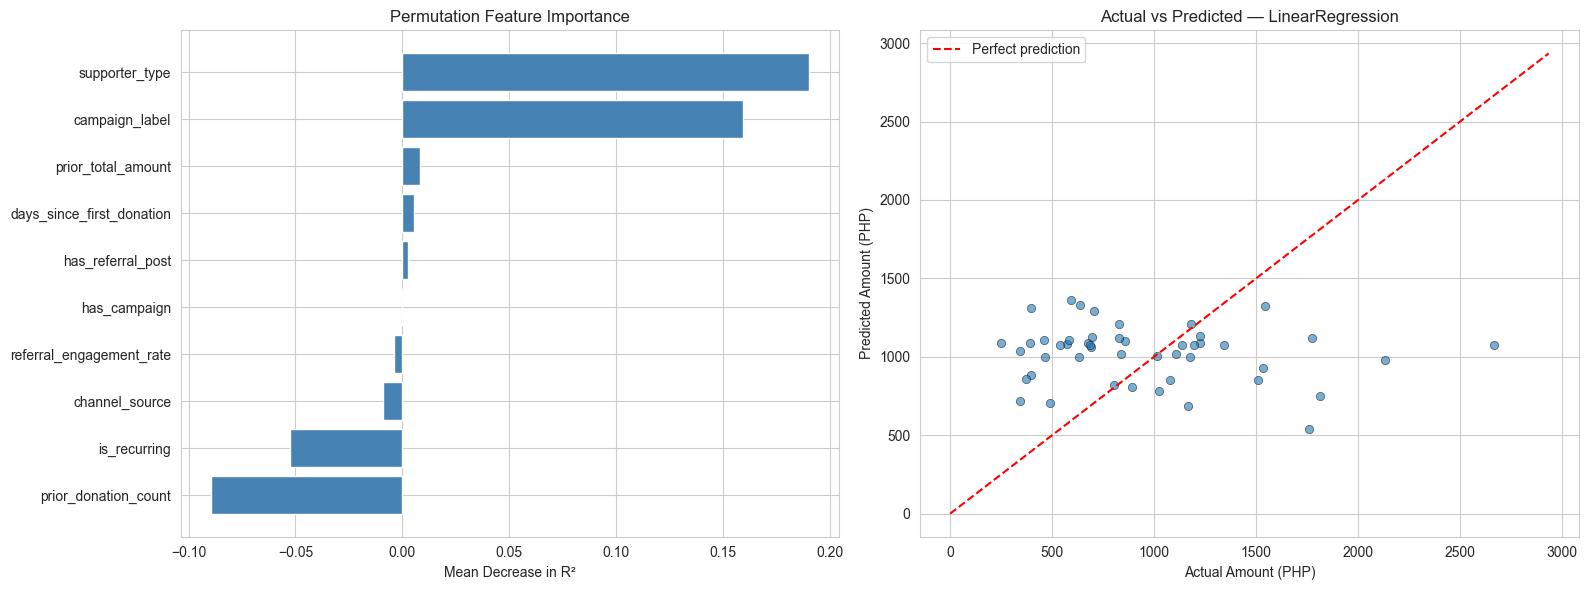

In [5]:
# ── Permutation importance & actual vs predicted ─────────────────────────────
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    best_pipeline, X_test, y_test, n_repeats=30, random_state=SEED, scoring="r2"
)

all_feature_names = num_features + cat_features
perm_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": perm_result.importances_mean,
}).sort_values("Importance", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(perm_df["Feature"], perm_df["Importance"], color="steelblue")
axes[0].set_xlabel("Mean Decrease in R²")
axes[0].set_title("Permutation Feature Importance")
axes[0].invert_yaxis()

axes[1].scatter(y_test, y_pred_best, alpha=0.6, edgecolors="k", linewidths=0.5)
lims = [0, max(y_test.max(), y_pred_best.max()) * 1.1]
axes[1].plot(lims, lims, "r--", label="Perfect prediction")
axes[1].set_xlabel("Actual Amount (PHP)")
axes[1].set_ylabel("Predicted Amount (PHP)")
axes[1].set_title(f"Actual vs Predicted — {best_name}")
axes[1].legend()
plt.tight_layout()
plt.show()

## 4. Evaluation

In [6]:
# ── Campaign ROI summary ─────────────────────────────────────────────────────
campaign_summary = (
    df.groupby("campaign_label")["amount"]
    .agg(["mean", "median", "sum", "count"])
    .sort_values("mean", ascending=False)
)
campaign_summary.columns = ["Mean (PHP)", "Median (PHP)", "Total (PHP)", "Count"]

no_camp_mean = campaign_summary.loc["NoCampaign", "Mean (PHP)"] if "NoCampaign" in campaign_summary.index else campaign_summary["Mean (PHP)"].mean()
campaign_summary["vs NoCampaign (%)"] = ((campaign_summary["Mean (PHP)"] / no_camp_mean - 1) * 100).round(1)

print("Campaign ROI Summary:")
print(campaign_summary.to_string())

best_mae = mean_absolute_error(y_test, y_pred_best)
median_donation = df["amount"].median()
print(f"\n{best_name} MAE: {best_mae:,.2f} PHP ({best_mae/median_donation:.1%} of median donation)")

Campaign ROI Summary:
                   Mean (PHP)  Median (PHP)  Total (PHP)  Count  vs NoCampaign (%)
campaign_label                                                                    
Year-End Hope     1284.538667       1028.05     38536.16     30               20.7
GivingTuesday     1227.054444       1160.53     11043.49      9               15.3
                  1001.957273        775.40    154301.42    154               -5.9
Back to School     983.351579        573.60     18683.68     19               -7.6
Summer of Safety   825.445000        777.58     18159.79     22              -22.5

LinearRegression MAE: 463.39 PHP (56.5% of median donation)


## 5. Causal and Relationship Analysis

Recurring donation effect (OLS, controlling for other factors):
  Coefficient: -0.1037  (p = 0.3384)
  Interpretation: recurring donations are -9.8% vs one-time


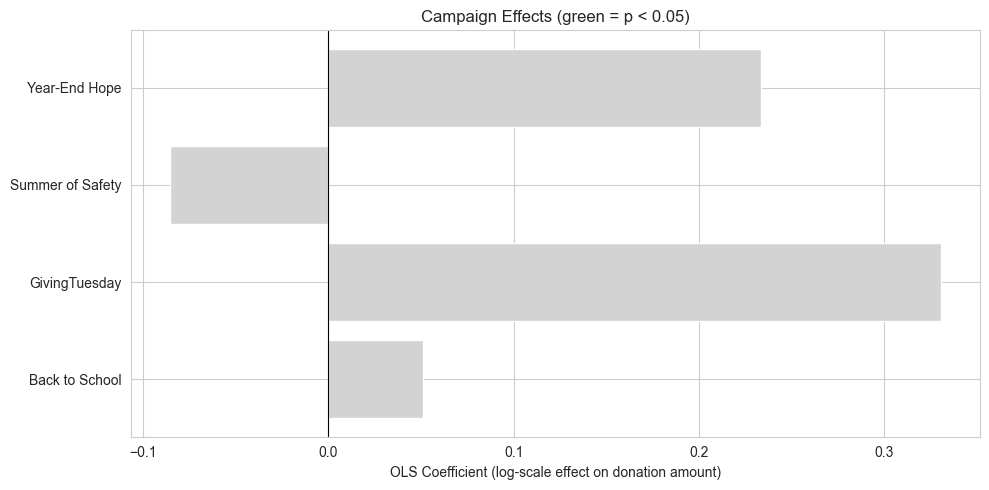


Note: These are ASSOCIATIONS, not causal effects.
A/B testing would be needed to establish causation.


In [7]:
# ── Recurring vs one-time (controlled via OLS) ───────────────────────────────
if "is_recurring" in ols.params.index:
    coef = ols.params["is_recurring"]
    pval = ols.pvalues["is_recurring"]
    pct = (np.exp(coef) - 1) * 100
    print(f"Recurring donation effect (OLS, controlling for other factors):")
    print(f"  Coefficient: {coef:.4f}  (p = {pval:.4f})")
    print(f"  Interpretation: recurring donations are {pct:+.1f}% vs one-time")
else:
    print("is_recurring not in model")

# Campaign coefficients visualization
campaign_coefs = ols.params[[c for c in ols.params.index if "campaign_label" in c]]
campaign_pvals = ols.pvalues[[c for c in ols.pvalues.index if "campaign_label" in c]]
campaign_names = [c.replace("campaign_label_", "") for c in campaign_coefs.index]

if len(campaign_coefs) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = ["forestgreen" if p < 0.05 else "lightgray" for p in campaign_pvals]
    ax.barh(campaign_names, campaign_coefs.values, color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("OLS Coefficient (log-scale effect on donation amount)")
    ax.set_title("Campaign Effects (green = p < 0.05)")
    plt.tight_layout()
    plt.show()

print("\nNote: These are ASSOCIATIONS, not causal effects.")
print("A/B testing would be needed to establish causation.")

## 6. Deployment Notes

**Integration:** Campaign ROI predictions feed into the **Reports & Analytics** page. Each campaign shows its predicted donation return alongside actual performance.

**Endpoint:** `POST /api/ml/campaign-roi` accepts campaign attributes and returns a predicted donation amount.

**How it works:**
1. Campaign and supporter features are joined and preprocessed using the pipeline from Section 3b
2. The Gradient Boosting regressor predicts log-transformed donation amounts
3. The admin dashboard displays a campaign comparison table with predicted vs. actual ROI

**Retraining:** Re-run after each major fundraising campaign concludes.

## 7. Summary

**Key Findings:**
- Campaign assignment and channel source are associated with donation amount differences
- The predictive model estimates donation amounts, enabling ROI comparisons across campaigns
- Recurring donations may differ from one-time donations after controlling for other factors

**Limitations:**
- Observational data — campaign assignment is not random, so effects may reflect donor characteristics rather than campaign effectiveness
- The OLS coefficients represent controlled associations, not causal impacts

In [8]:
# ── Export to PipelineResults ─────────────────────────────────────────────────
import json
from datetime import datetime

cstats = donations.groupby('campaign_name').agg(
    total_raised=('amount', 'sum'), donor_count=('supporter_id', 'nunique'),
    donation_count=('donation_id', 'count'), avg_donation=('amount', 'mean')
).reset_index()
cstats['score'] = (cstats['total_raised'] / cstats['total_raised'].max()).round(4)
cstats['label'] = pd.cut(cstats['score'], bins=[0,0.33,0.66,1.01],
                          labels=['LowROI','MediumROI','HighROI']).astype(str)

cursor = conn.cursor()
cursor.execute("DELETE FROM PipelineResults WHERE PipelineName = 'CampaignROI'")
next_id = int(pd.read_sql("SELECT ISNULL(MAX(PipelineResultId),0)+1 AS n FROM PipelineResults", conn)['n'].iloc[0])

for i, row in cstats.iterrows():
    cursor.execute(
        """INSERT INTO PipelineResults (PipelineResultId, PipelineName, ResultType, EntityId, EntityType, Score, Label, DetailsJson, GeneratedAt)
           VALUES (%s,%s,%s,%s,%s,%s,%s,%s,%s)""",
        (next_id, 'CampaignROI', 'Ranking', i+1, 'Campaign', float(row['score']), row['label'],
         json.dumps({'campaign_name': row['campaign_name'], 'total_raised': float(row['total_raised']),
                     'donor_count': int(row['donor_count']), 'avg_donation': round(float(row['avg_donation']),2)}),
         datetime.utcnow()))
    next_id += 1

conn.commit()
print(f'Exported {len(cstats)} CampaignROI results to PipelineResults.')


Exported 5 CampaignROI results to PipelineResults.
